# Vignette C: Perturbation-response prediction with LEMBAS

This vignette shows the full perturbation-response workflow using the macrophage dataset from
[Nilsson et al. 2022](https://doi.org/10.1038/s41467-022-30684-y).
We will:

1. Download the prior knowledge network and matched ligand / TF activity data
2. Format and construct the network graph
3. Split conditions into train and test sets
4. Fit a mean-response baseline and a ridge baseline
5. Fit the LEMBAS-RNN model (requires PyTorch)
6. Evaluate all three models per-readout and per-condition
7. Compare models under Leave-One-Out Cross-Validation (LOOCV)

> **Note:** steps 5–7 require `torch`. Install it with `pip install torch` if needed.

In [ ]:
import pandas as pd
import networkcommons as nc
from networkcommons.utils import lembas_format_network, network_from_df
from networkcommons.methods import (
    split_perturbation_data,
    run_mean_response_baseline,
    run_ridge_baseline,
    run_lembas_rnn,
    evaluate_predictions,
)

## 1. Load LEMBAS macrophage data

The macrophage dataset contains 23 stimulation conditions, 13 ligands and
89 TF readouts. The prior knowledge network has ~5 700 signed edges.
All files are cached locally after the first download.

In [2]:
net_df  = nc.data.omics.lembas_network('macrophage')
ligands = nc.data.omics.lembas_ligands('macrophage')
tfs     = nc.data.omics.lembas_tfs('macrophage')

print('Network edges :', len(net_df))
print('Conditions    :', len(ligands))
print('Ligand inputs :', ligands.shape[1])
print('TF readouts   :', tfs.shape[1])

Network edges : 5732
Conditions    : 23
Ligand inputs : 12
TF readouts   : 88


In [3]:
net_df.head()

,source,target,direction,stimulation,inhibition,sources,references
0,P49137,Q16539,1,0,0,BioGRID;ELM;HPRD;InnateDB;IntAct;KEGG;Lit-BM-1...,BioGRID:17395714;ELM:23047924;ELM:25255283;HPR...
1,Q16539,P49137,1,1,0,ACSN;BEL-Large-Corpus_ProtMapper;BioGRID;CA1;E...,ACSN:11274345;ACSN:12738796;ACSN:15187187;ACSN...
2,P31749,O15111,1,1,0,BioGRID;CancerCellMap;ELM;HPRD;HPRD-phos;HPRD_...,BioGRID:10485711;BioGRID:11278366;BioGRID:1571...
3,O15111,P19838,1,1,0,CancerCellMap;HPRD;HPRD-phos;HPRD_KEA;HPRD_MIM...,CancerCellMap:10469655;CancerCellMap:12482991;...
4,P19838,O15111,1,0,0,CancerCellMap;HPRD;InnateDB;IntAct;NetPath;Wang,CancerCellMap:10469655;CancerCellMap:12482991;...


In [4]:
ligands.head()

,Ligand_GC,Ligand_IC,Ligand_IFNb,Ligand_IFNg,Ligand_IL10,Ligand_IL13,Ligand_IL4,Ligand_LPSc,Ligand_P3C,Ligand_PGE2,Ligand_TNFa,Ligand_upLPS
condition,,,,,,,,,,,,
CON,0,0,0,0,0,0,0,0,0,0,0,0
GC,1,0,0,0,0,0,0,0,0,0,0,0
IFNb,0,0,1,0,0,0,0,0,0,0,0,0
IFNb+TNFa+PGE2+P3C,0,0,1,0,0,0,0,0,1,1,1,0
IFNb+TNFa+PGE2+P3C+IFNg,0,0,1,1,0,0,0,0,1,1,1,0


## 2. Build the prior knowledge network

`lembas_format_network` converts the binary `stimulation` / `inhibition` columns
into a single signed `mode_of_action` column (+1 / −1 / 0.1 for unknown).
`network_from_df` then wraps the edge table in a NetworkX `DiGraph`.

In [5]:
net_df = lembas_format_network(net_df)
graph  = network_from_df(net_df, source_col='source', target_col='target')

print('Nodes:', graph.number_of_nodes())
print('Edges:', graph.number_of_edges())

Nodes: 1128
Edges: 5732


## 3. Train / test split

`split_perturbation_data` aligns the ligand and TF matrices on shared
condition indices before splitting, so row order mismatches are handled
automatically.

In [6]:
x_train, x_test, y_train, y_test = split_perturbation_data(
    ligands,
    tfs,
    test_size=0.2,
    seed=42,
)

print('Train conditions:', len(x_train))
print('Test  conditions:', len(x_test))

Train conditions: 18
Test  conditions: 5


## 4. Baseline models

### 4a. Mean-response baseline

Predicts every test condition as the column-wise training mean — a
useful lower bound that ignores which ligand was applied.

In [7]:
mean_result = run_mean_response_baseline(y_train, x_test)
mean_metrics_readout   = evaluate_predictions(y_test, mean_result['predictions'], axis='readout')
mean_metrics_condition = evaluate_predictions(y_test, mean_result['predictions'], axis='condition')
mean_metrics_readout

,mse,mae,pearson
readout,,,
P10275,0.055365,0.202744,NaN
P18846,0.024692,0.108155,NaN
P15336,0.025660,0.129183,NaN
P18848,0.108065,0.301972,NaN
O14867,0.005940,0.065869,NaN
...,...,...,...
P19544,0.025075,0.125741,NaN
P25490,0.012948,0.093204,NaN
Q86T24,0.012577,0.073602,NaN


### 4b. Ridge regression baseline

Fits a linear map from ligand inputs to TF outputs using L2 regularisation.
This captures linear dose–response relationships without any network structure.

In [8]:
ridge_result = run_ridge_baseline(x_train, y_train, x_test)
ridge_metrics_readout   = evaluate_predictions(y_test, ridge_result['predictions'], axis='readout')
ridge_metrics_condition = evaluate_predictions(y_test, ridge_result['predictions'], axis='condition')
ridge_metrics_readout

,mse,mae,pearson
readout,,,
P10275,0.032979,0.151807,0.674693
P18846,0.014590,0.101729,0.701009
P15336,0.025182,0.137273,0.420488
P18848,0.051267,0.187548,0.849865
O14867,0.004186,0.056981,0.400249
...,...,...,...
P19544,0.020862,0.111261,0.603908
P25490,0.005275,0.064551,0.721711
Q86T24,0.017330,0.081920,0.356591


## 5. LEMBAS-RNN

The LEMBAS recurrent neural network constrains its weight matrix to the
signed prior knowledge network. Node states are propagated with the
Michaelis-Menten-like (MML) activation until steady state, and the
training loss combines MSE, sign regularisation and a uniform-distribution
penalty that keeps node states spread across [0, 1].

> **Requires `torch`.**

/nfs/research/saezrodriguez/hakem/project/networkcommons/networkcommons/methods/_perturbation.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.as_tensor(source_idx, dtype=torch.long, device=device),


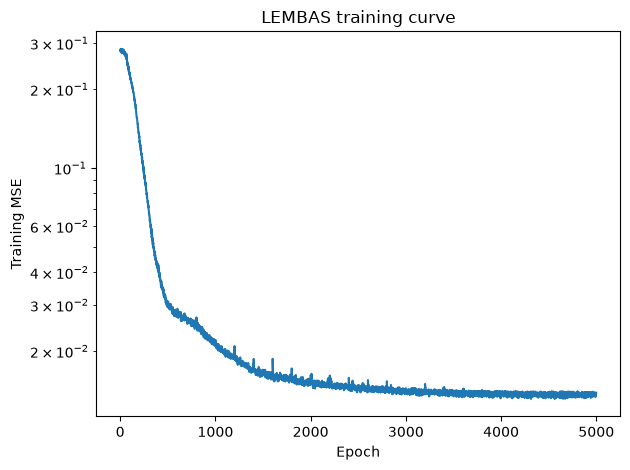

In [9]:
lembas_result = run_lembas_rnn(
    graph,
    x_train,
    y_train,
    x_test,
    seed=42,
    verbose=True,
)

import matplotlib.pyplot as plt
plt.plot(lembas_result['loss_history'])
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.title('LEMBAS training curve')
plt.yscale('log')
plt.tight_layout()
plt.show()

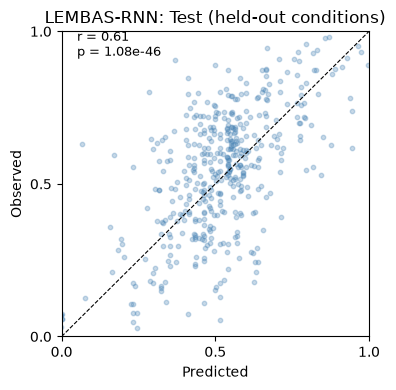

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Scatter: predicted vs. observed (all test conditions × all TFs)
# Reproduces the style of SI Figure 15B from Nilsson et al. 2022
y_true_vals = y_test.values.ravel()
y_pred_vals = lembas_result['predictions'].values.ravel()
r, p = pearsonr(y_pred_vals, y_true_vals)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(y_pred_vals, y_true_vals, alpha=0.3, s=10, color='steelblue')
lims = [0, 1]
ax.plot(lims, lims, 'k--', linewidth=0.8)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Predicted')
ax.set_ylabel('Observed')
ax.set_title('LEMBAS-RNN: Test (held-out conditions)')
ax.text(0.05, 0.92, f'r = {r:.2f}\np = {p:.2e}', transform=ax.transAxes, fontsize=9)
ax.set_xticks([0, 0.5, 1])
ax.set_yticks([0, 0.5, 1])
plt.tight_layout()
plt.show()

## 6. Evaluation

### 6a. Per-readout metrics

`axis='readout'` (default) reports MSE, MAE and Pearson correlation for
each TF across all test conditions, plus an `__all__` aggregate row.

In [11]:
lembas_metrics_readout = evaluate_predictions(
    y_test,
    lembas_result['predictions'],
    axis='readout',
)
lembas_metrics_readout

,mse,mae,pearson
readout,,,
P10275,0.020117,0.133575,0.898132
P18846,0.024675,0.108221,NaN
P15336,0.048093,0.178585,0.421162
P18848,0.036797,0.170911,0.769406
O14867,0.005933,0.065822,NaN
...,...,...,...
P19544,0.025110,0.125784,NaN
P25490,0.016140,0.120618,0.206768
Q86T24,0.012571,0.073691,NaN


### 6b. Per-condition metrics

`axis='condition'` reports the same metrics for each held-out condition
across all TF readouts — useful for spotting which stimulations the model
finds hardest to predict.

In [12]:
lembas_metrics_condition = evaluate_predictions(
    y_test,
    lembas_result['predictions'],
    axis='condition',
)
lembas_metrics_condition.sort_values('mse', ascending=False)

,mse,mae,pearson
condition,,,
IL4+upLPS,0.042550,0.165154,0.468529
TNFa,0.031240,0.139923,0.447432
__all__,0.028633,0.133027,0.612681
TNFa+PGE2,0.027714,0.134502,0.684590
TNFa+P3C,0.021224,0.114395,0.663480
upLPS+IFNg,0.020435,0.111159,0.758554


### 6c. Model comparison

Global aggregate metrics (`__all__` flattens all condition × TF values — identical for both axes).
The **median per-readout Pearson** and **median per-condition Pearson** are different: they
summarise the distribution of the per-TF and per-condition correlation scores respectively,
giving a sense of consistency across readouts and conditions.

In [14]:
models = {
    'Mean baseline': (mean_metrics_readout,   mean_metrics_condition),
    'Ridge'        : (ridge_metrics_readout,  ridge_metrics_condition),
    'LEMBAS-RNN'   : (lembas_metrics_readout, lembas_metrics_condition),
}

# Global aggregate (identical for both axes — shown once)
comparison = pd.DataFrame({
    name: r.loc['__all__'] for name, (r, _) in models.items()
}).T
comparison.index.name = 'model'

# Median Pearson per readout (TF) and per condition — these differ between models
comparison['median_pearson_readout'] = [
    r.drop('__all__')['pearson'].median() for _, (r, _) in models.items()
]
comparison['median_pearson_condition'] = [
    c.drop('__all__')['pearson'].median() for _, (_, c) in models.items()
]
comparison

,mse,mae,pearson,median_pearson_readout,median_pearson_condition
model,,,,,
Mean baseline,0.045023,0.167167,0.235613,1.306326e-16,0.235434
Ridge,0.032988,0.141908,0.542425,5.912434e-01,0.500453
LEMBAS-RNN,0.028633,0.133027,0.612681,5.277008e-01,0.663480


## 7. Leave-One-Out Cross-Validation (LOOCV)

The original Nilsson et al. 2022 paper trains one model per condition (leaving it out) and
aggregates predictions. This gives a more honest evaluation than a single 80/20 split
because every condition serves as the test set exactly once.

Set `n_loocv = 3` below for a quick demo (≈ 3 × training time).  
Change it to `len(conditions)` to reproduce the full 23-fold LOOCV.

All three models — mean baseline, ridge, and LEMBAS — are trained and evaluated under
the same LOOCV protocol so the comparison is fair.

In [15]:
import numpy as np

# ── LOOCV parameters ───────────────────────────────────────────────────────────
# n_loocv=3 runs a quick 3-fold demo (≈ 3× training time per model).
# Set to len(conditions) for the full LOOCV used in the original paper.
n_loocv = 3
# ──────────────────────────────────────────────────────────────────────────────

conditions = ligands.index.tolist()
rng = np.random.RandomState(42)
loocv_cond_idx = sorted(rng.choice(len(conditions), size=n_loocv, replace=False))
loocv_conditions = [conditions[i] for i in loocv_cond_idx]

loocv_true = []
loocv_pred = {'Mean': [], 'Ridge': [], 'LEMBAS': []}

for fold, test_cond in enumerate(loocv_conditions):
    train_conds = [c for c in conditions if c != test_cond]
    x_tr = ligands.loc[train_conds]
    y_tr = tfs.loc[train_conds]
    x_te = ligands.loc[[test_cond]]
    y_te = tfs.loc[[test_cond]]

    print(f'Fold {fold + 1}/{n_loocv}: held out "{test_cond}"')

    loocv_true.append(y_te)

    mean_res = run_mean_response_baseline(y_tr, x_te)
    loocv_pred['Mean'].append(mean_res['predictions'])

    ridge_res = run_ridge_baseline(x_tr, y_tr, x_te)
    loocv_pred['Ridge'].append(ridge_res['predictions'])

    lembas_res = run_lembas_rnn(graph, x_tr, y_tr, x_te, epochs=2000, seed=42, verbose=False)
    loocv_pred['LEMBAS'].append(lembas_res['predictions'])

y_loocv_true = pd.concat(loocv_true)
loocv_pred   = {k: pd.concat(v) for k, v in loocv_pred.items()}
print('Done. Held-out conditions:', y_loocv_true.index.tolist())

Fold 1/3: held out "CON"
Fold 2/3: held out "IL4"
Fold 3/3: held out "PGE2"
Done. Held-out conditions: ['CON', 'IL4', 'PGE2']


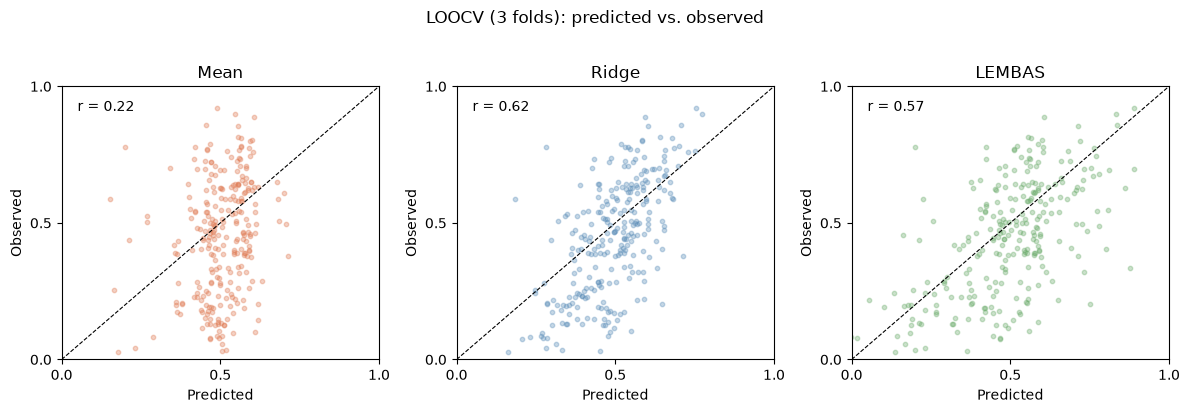

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Predicted vs. observed scatter for each model across all held-out conditions
# Follows the style of SI Figure 15B from Nilsson et al. 2022
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = {'Mean': '#e07b54', 'Ridge': '#5b8db8', 'LEMBAS': '#6aab6a'}

for ax, (model_name, preds) in zip(axes, loocv_pred.items()):
    y_true = y_loocv_true.values.ravel()
    y_pred = preds.values.ravel()
    r, _ = pearsonr(y_pred, y_true)
    ax.scatter(y_pred, y_true, alpha=0.35, s=10, color=colors[model_name])
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Observed')
    ax.set_title(model_name)
    ax.text(0.05, 0.91, f'r = {r:.2f}', transform=ax.transAxes, fontsize=10)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])

plt.suptitle(
    f'LOOCV ({n_loocv} fold{"s" if n_loocv > 1 else ""}): predicted vs. observed',
    y=1.02,
)
plt.tight_layout()
plt.show()

In [17]:
# Aggregate LOOCV metrics and compare across all three models
loocv_metrics = {
    model: evaluate_predictions(y_loocv_true, preds, axis='condition').loc['__all__']
    for model, preds in loocv_pred.items()
}
loocv_comparison = pd.DataFrame(loocv_metrics).T
loocv_comparison.index.name = 'model'
print(f'=== LOOCV model comparison ({n_loocv} folds) ===')
loocv_comparison

=== LOOCV model comparison (3 folds) ===


,mse,mae,pearson
model,,,
Mean,0.047062,0.178238,0.218967
Ridge,0.029725,0.139944,0.618838
LEMBAS,0.034174,0.144970,0.574358
